In [2]:
import numpy as np

from IPython.display import Image

# Valid Convolution, Circular Convolution, and Overlap-Add methods <br>to compute Sliding Dot Product!

The sliding dot product (SDP) of a query, `Q`, and a time series, `T`, is an array of length `len(T) - len(Q) + 1`, where the $i^{th}$ element is the dot product between `Q` and `T[i:i+len(Q)]`. In the following sections, we will explain how it is related to convolution, and how it can be computed faster when arrays are large.

## Valid Convolution

An easy way to grasp convolution is to understand it via its flip-and-slide form [(See section 4.1.6 of Introduction to Signal Processing by Orfanidis)](https://www.amazon.com/Introduction-Signal-Processing-Sophocles-Orfanidis/dp/0132091720/ref=sr_1_1?dib=eyJ2IjoiMSJ9.KazpLCcWASczX1BqPnOFCPe9I6t9UJQZCCDSfmeVN4Q.eQ6V1-Ht0LQrC95afdw-bar36hTQe1KQD1_ZaOnhpHE&dib_tag=se&qid=1776127943&refinements=p_27%3ASophocles+J.+Orfanidis&s=books&sr=1-1)! The convolution between two finite arrays is calculated when **one array is flipped and slid along the other array. At each time (step), the output sample is obtained by computing the dot product of overlapping elements**.  The "valid convolution" between two arrays is computed by flipping the shorter array and sliding it along the longer array, and computing the dot product when there is a full overlap. Therefore, the SDP between `T` and `Q` is equivalent to the valid convolution between `T` and  `Qr=Q[::-1]`.

**Example:**
<br> 
Suppose `T = [1, 2, 3, 4, 5]` and `Q = [1, 2, 3]`. Their SDP is `[14, 20, 26]`. Recall that this is equivalent to the valid convolution between `T = [1, 2, 3, 4, 5]` and `Qr = [3, 2, 1]`.

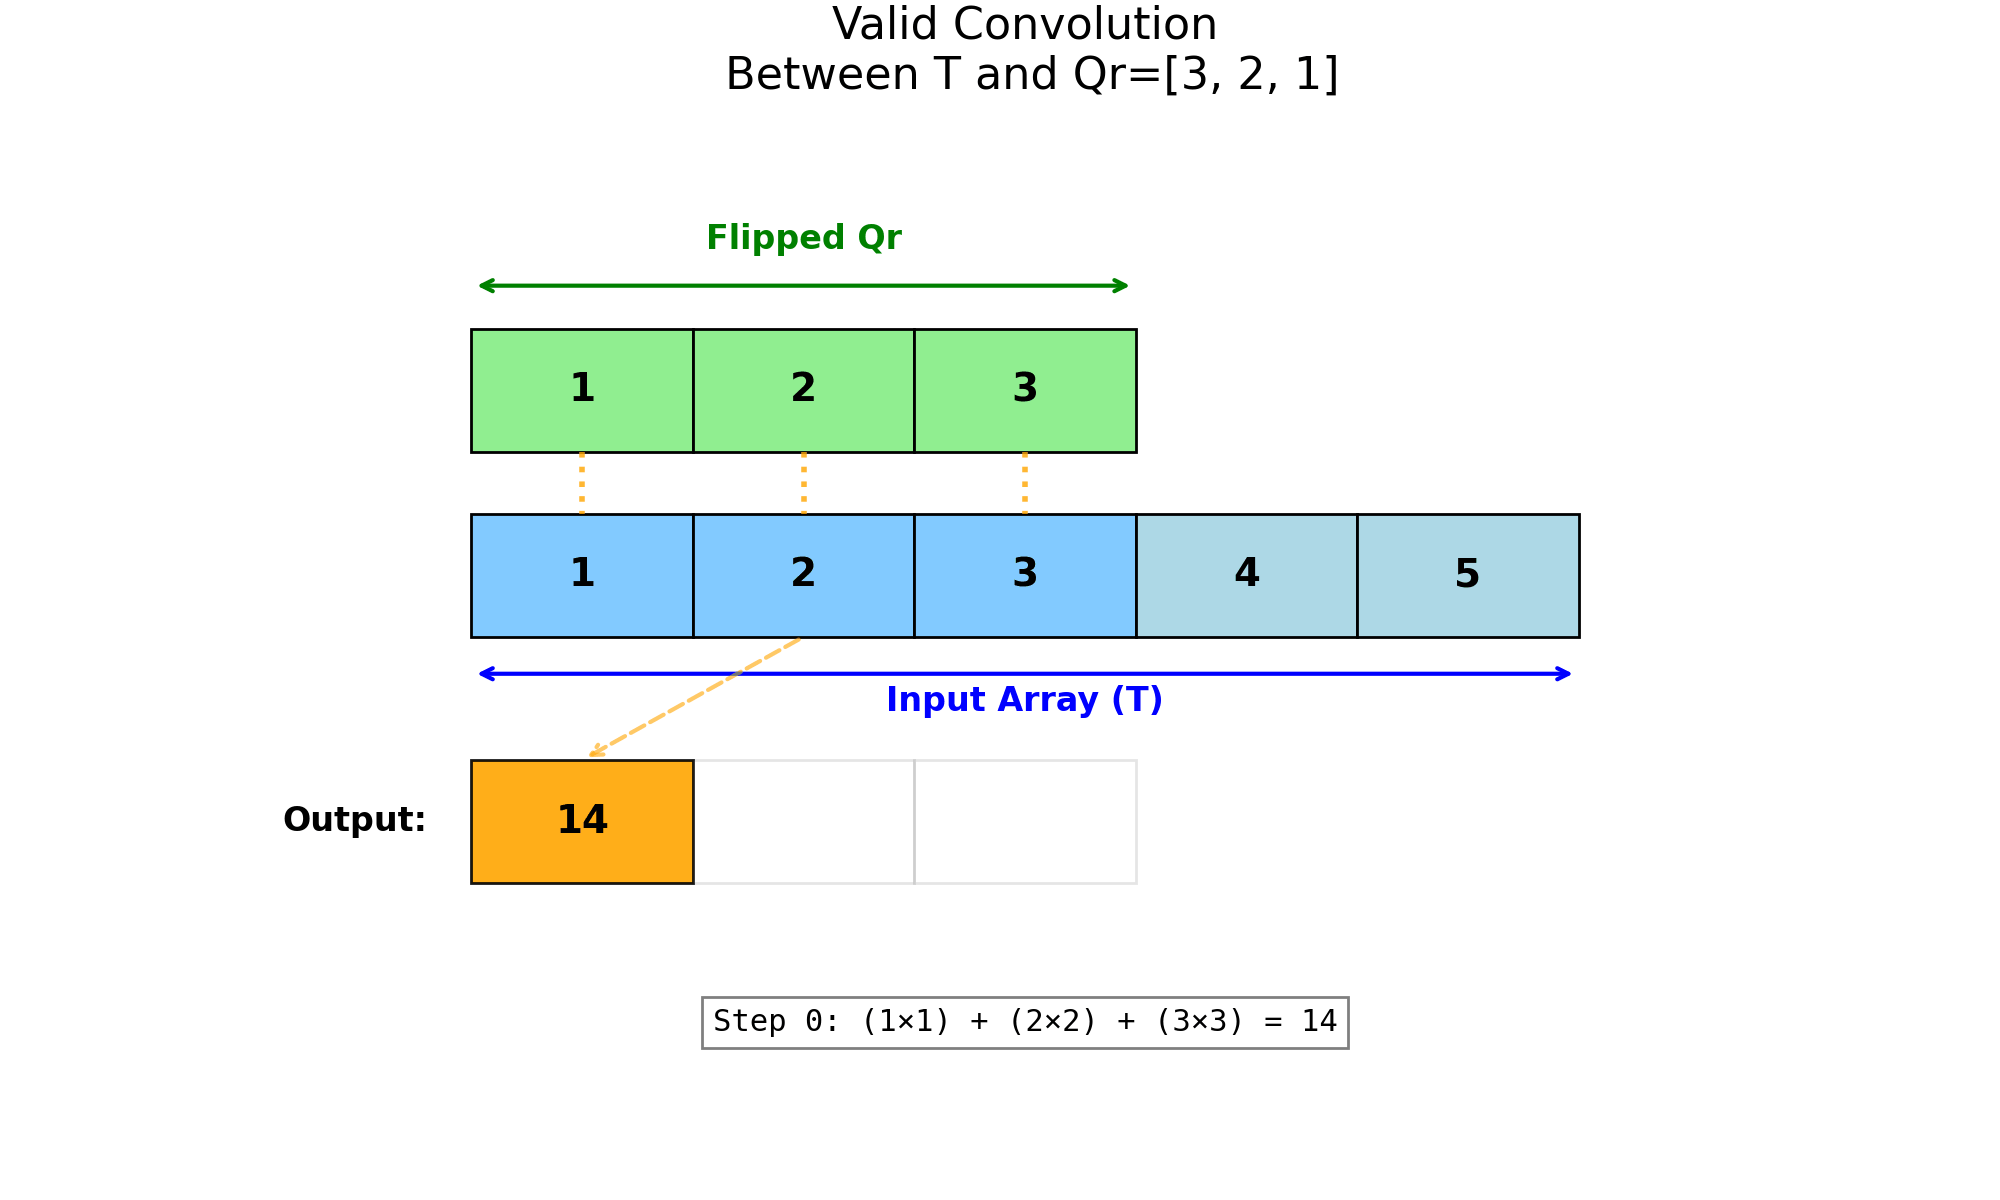

In [3]:
Image(filename='valid_convolution.gif', width=800, height=300)

Notice that the `Qr` is flipped and slid along the array `T`. The `Flipped Qr` is the same as `Q`, meaning the output above is the SDP between `T` and `Q`. From this point onwards, we will forget about `Q` and focus on the "valid convolution" between `T` and `Qr`. The time complexity of valid convolution via flip-and-slide form, as shown above, is $O(nm)$, where `n=len(T)` and `m=len(Qr)`. For large arrays, this can be computed faster with the help of `FFT`, which comes into the picture in "circular convolution". But first, let's understand the circular convolution and see how it is related to the valid convolution.

## Circular Convolution

As we will see shortly, the valid convolution can be computed via circular convolution. The circular convolution is [defined as the convolution between two periodic sequences that have the same period 'N'](https://en.wikipedia.org/wiki/Circular_convolution). The output will also be a periodic sequence with the same period as inputs'. Let's revisit our example from the previous section, and compute the circular convolution between `T = [1, 2, 3, 4, 5]` and `Qr=[3, 2, 1]`. Hold on! That cannot happen since their periods do not have the same length! Let's pad `Qr` with zeros till its length becomes the same as `len(T)`. In what follows, we'll compute the ciruclar convolution between `T = [1, 2, 3, 4, 5]` and `Qr_padded=[3, 2, 1, 0, 0]` using the following steps:

1. Flip the `Qr_padded` array
2. Slide the flipped `Qr_padded` array across `T` starting from where there is at least one overlapping element
3. For other elements of a sequence, its corresponding element from the other sequence can be obtained since sequences are periodic

To be more precise, this is only one period of output, and it is called length-N circular convolution, where `N` is the length of the period.

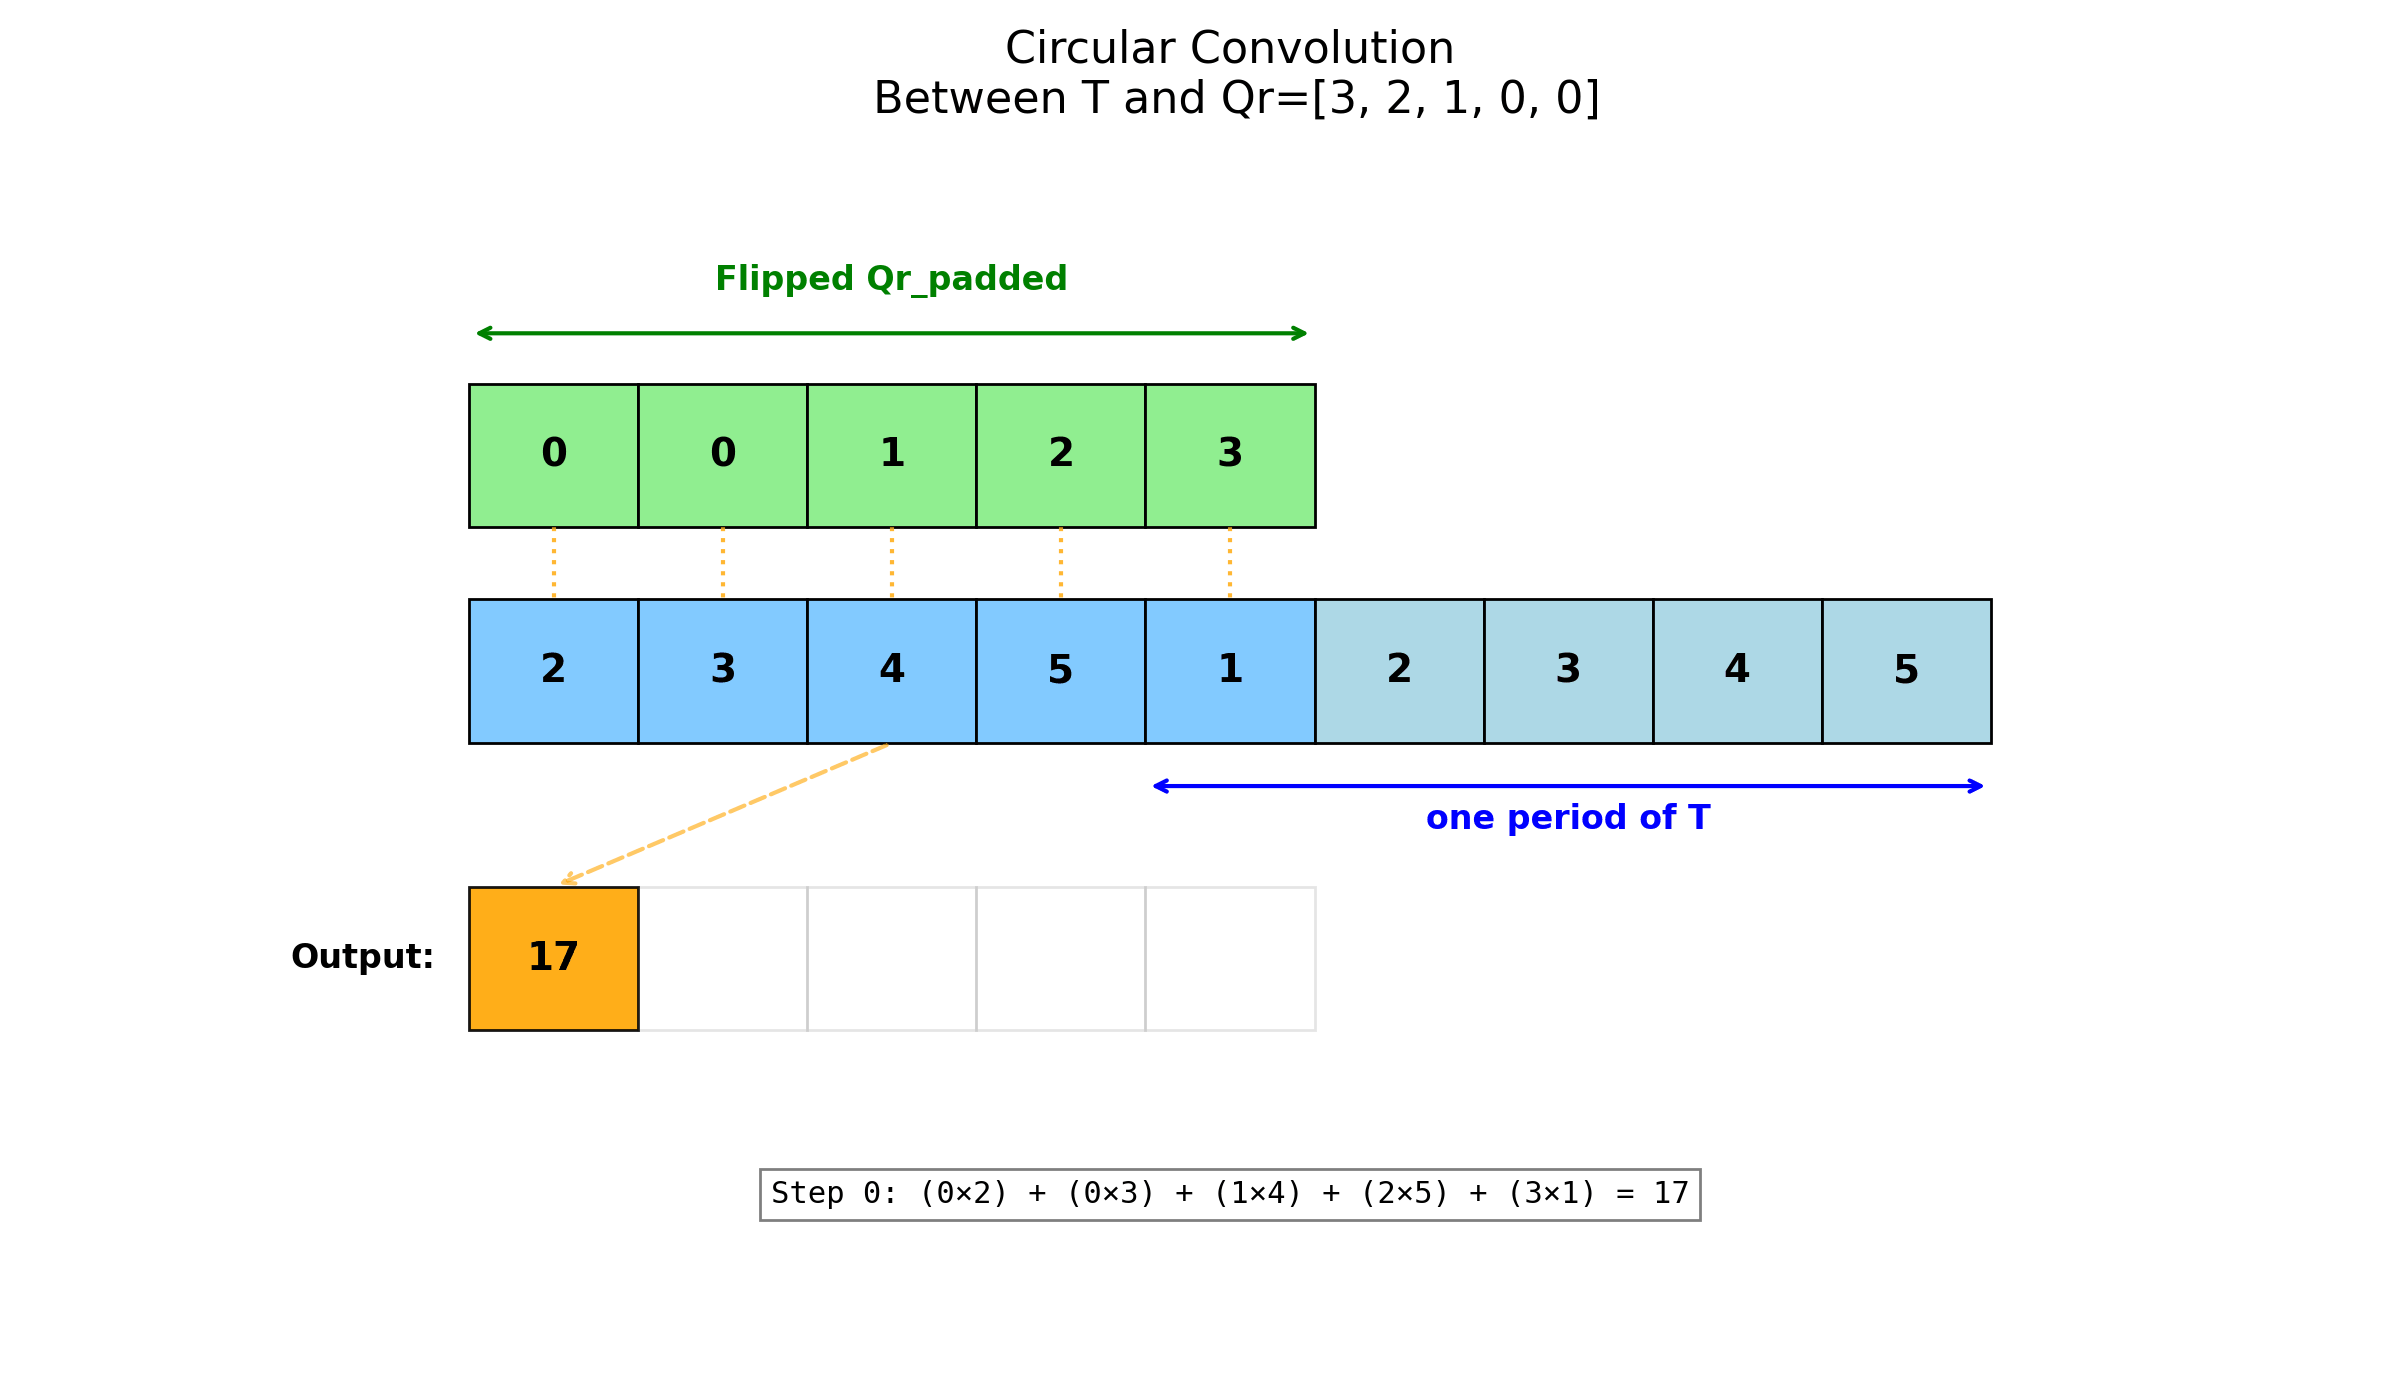

In [4]:
Image(filename='convolution_annotated_circular.gif', width=800, height=300)

The animation above shows the length-N circular convolution in time domain, where `N` is the length of period. Note that the `slice(2, 5)` of output is `[14, 20, 26]`, which is the same as the valid convolution computed before! So, we can calculate the valid convolution between `T` and `Qr` by first computing the length-5 circular convolution between `T` and `Qr_padded`, and then getting the `slice(2, 5)` of it.  This can be computed in the frequency domain as follows: `IFFT(FFT(T) * FFT(Qr_padded))`

In [5]:
T = np.array([1, 2, 3, 4, 5]).astype(np.float64)
Qr_paded = np.array([3, 2, 1, 0, 0]).astype(np.float64)

out = np.fft.ifft(np.fft.fft(T) * np.fft.fft(Qr_paded))
out

array([17.+0.j, 13.+0.j, 14.+0.j, 20.+0.j, 26.+0.j])

and we can get the sliding dot product using `out.real[2:5]`, which gives the expected value `[14, 20, 26]`

## Overlap-add Convolution

So far, we learned that we can use (FFT-based) circular convolution between `T` and `Qr_padded` to compute the valid convolution between  `T` and `Qr`. It turns out that there is a way to achieve the valid convolution on large arrays by performing several circular convolutions on chunks of the arrays. The [overlap-add method](https://en.wikipedia.org/wiki/Overlap–add_method) is a common approach that can make the computation faster if the chunk size is chosen optimally but let's set that aside for now and simply focus on how the method works.

**Example:**
<br>
`T = [1, 2, 3, ..., 10]` and `Qr = [3, 2, 1]`.  Their "valid convolution" is `[14, 20, 26, 32, 38, 44, 50, 56]`. In circular convolution, `Qr` is padded with zeros till its length becomes the same as `len(T)`. In **overlap-add method**, however, we first break `T` into smaller NON-overlapping chunks. For instance, let's consider `chunk_size=5`. Therefore, `T` can be chunked into `T1=[1, 2, 3, 4, 5]` and `T2=[6, 7, 8, 9, 10]`. Notice that we are losing the subsequences `4, 5, 6` and `5, 6, 7` since the elements of each of those two subsequences do not sit on a single chunk. To handle those, each chunk needs to be padded with `len(Qr)-1` zeros so that the `overlap-add` method can re-construct the "valid convolution" output at the end.

* T1_padded = [1, 2, 3, 4, 5, 0, 0]
* T2_padded = [6, 7, 8, 9, 10, 0, 0] 

We now calculate the circular convolution between each padded chunk with length `chunk_size + len(Qr) - 1` and `Qr_padded`, which is `Qr` but padded with zeros till its length becomes equal to `chunk_size + len(Qr) - 1`. In this case: `Qr_padded = [3, 2, 1, 0, 0, 0, 0]`

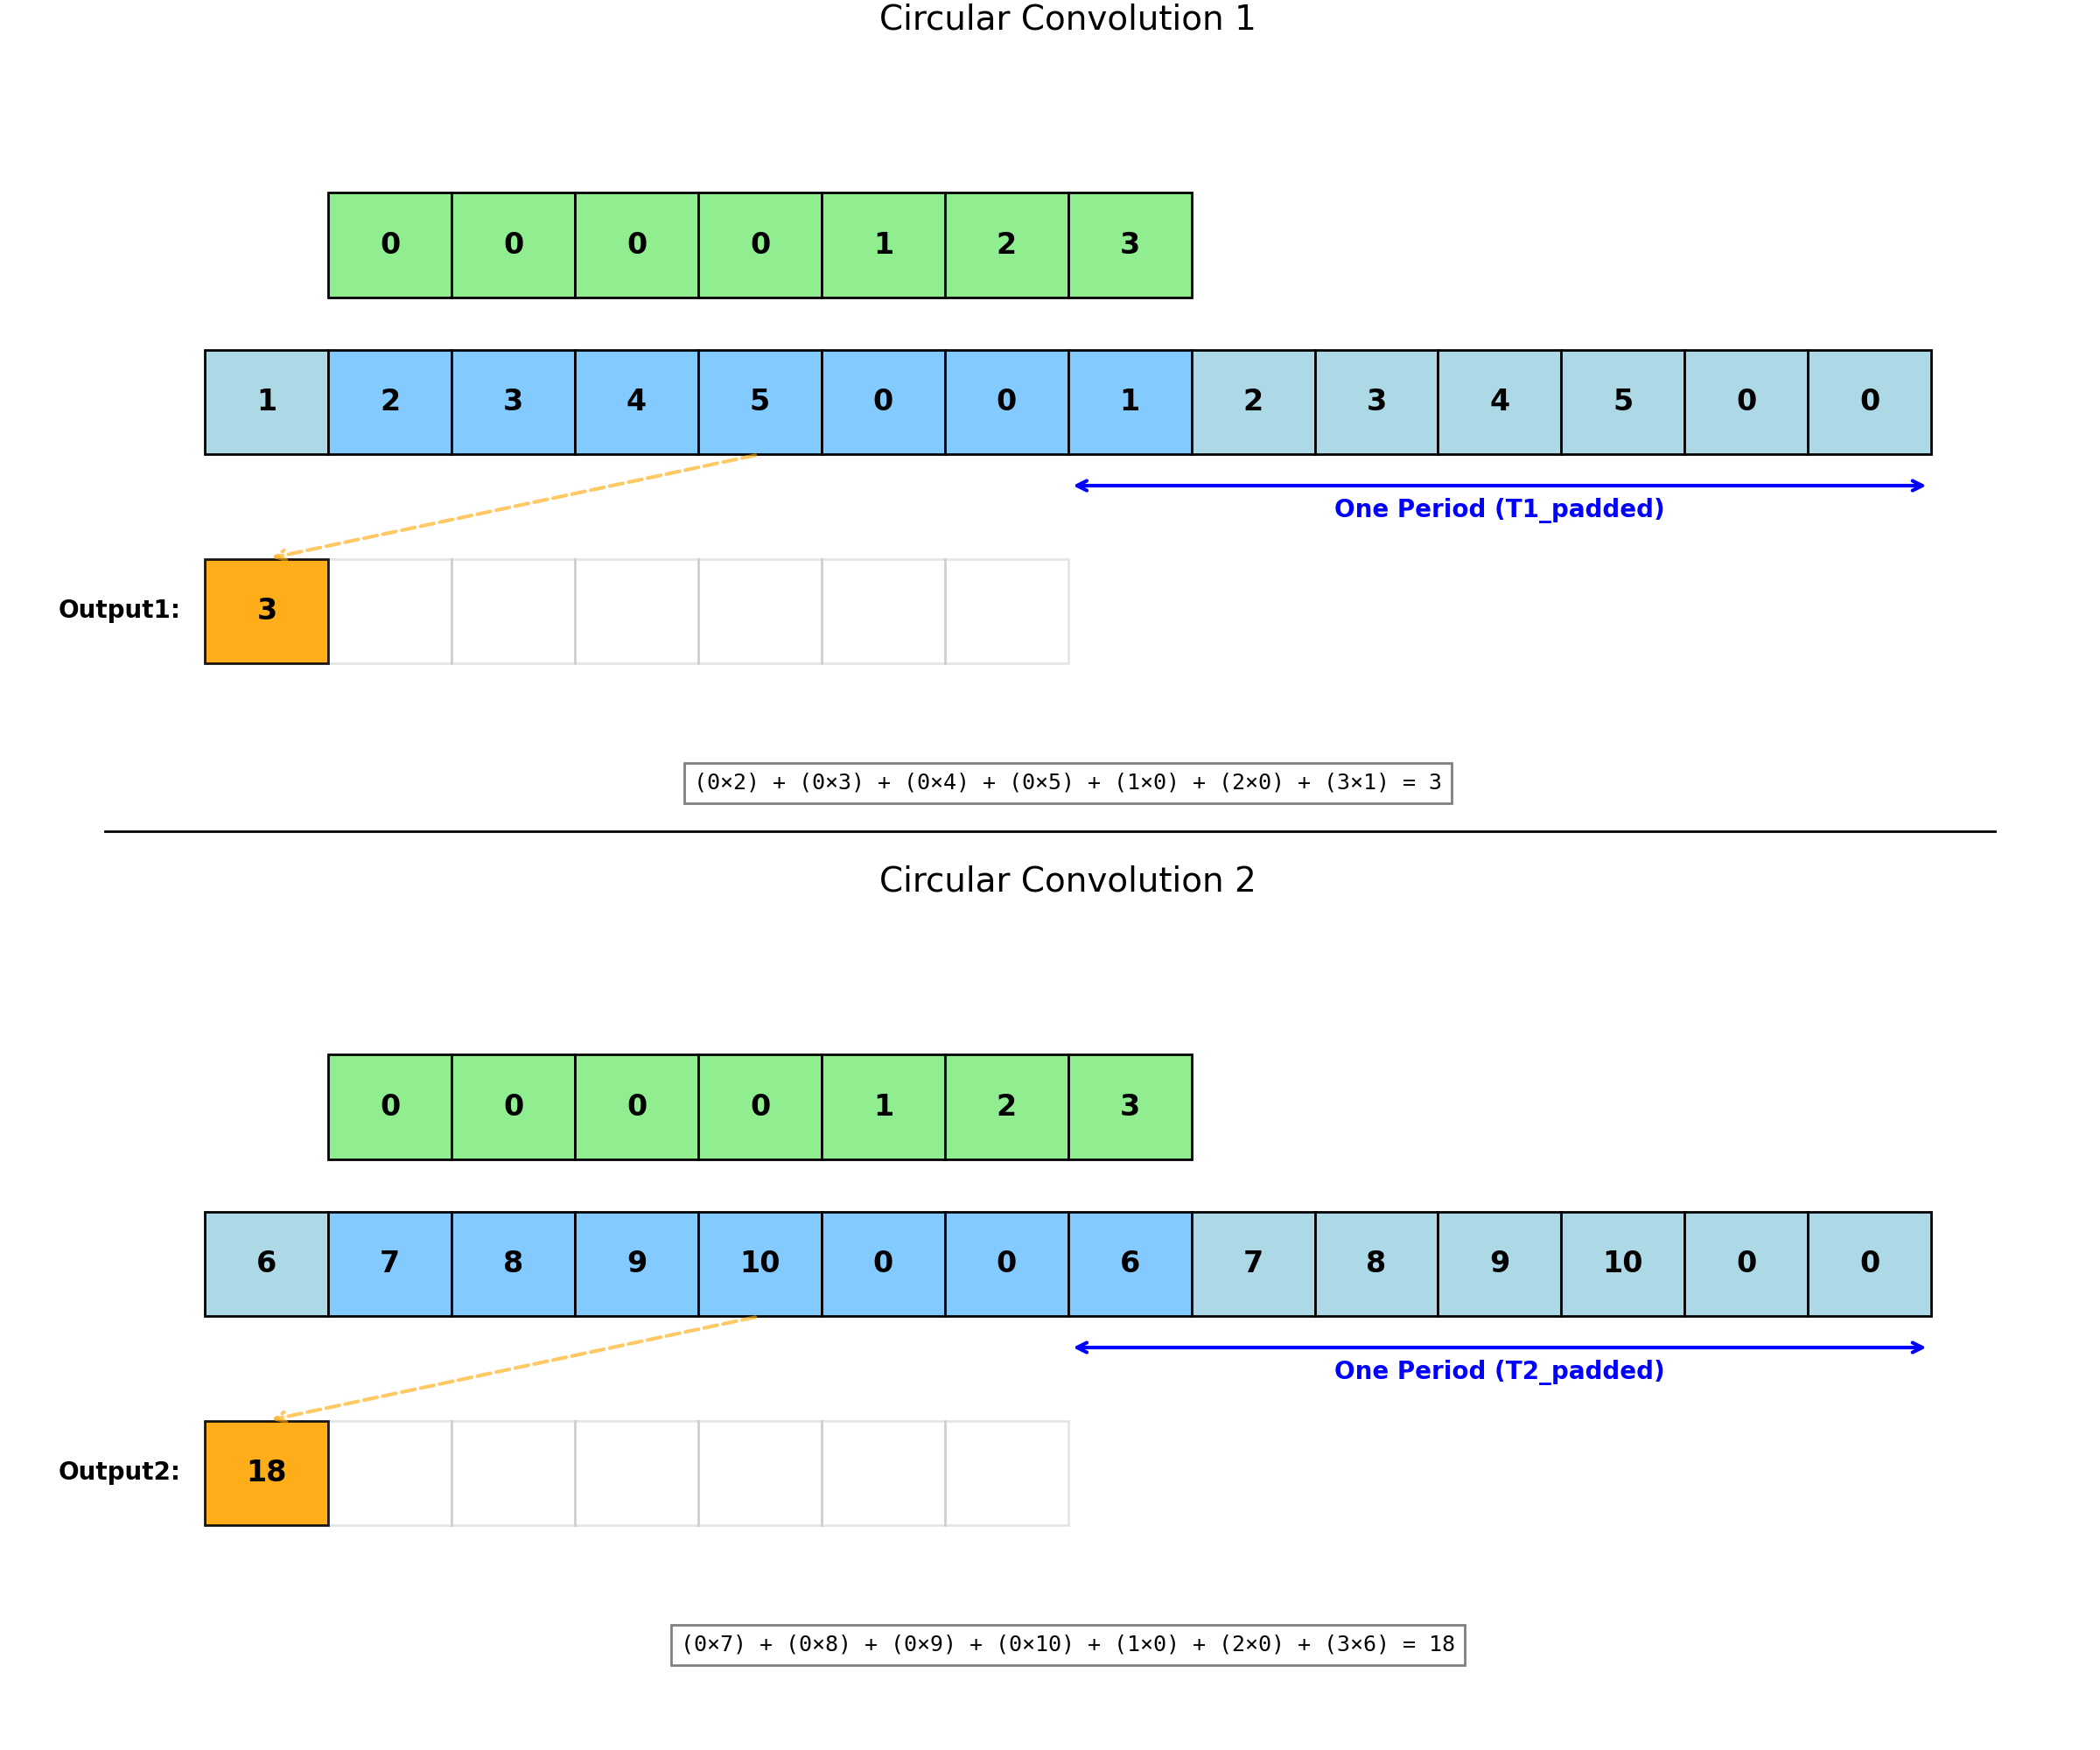

In [19]:
Image(filename='dual_convolution.gif', width=800, height=300)

Once the circular convolutons are computed, we can combine(overlap) the outputs by adding the `m-1` elements at the tail of the each chunk's output to the `m-1` elements at the head of the next chunk's output. This is because chunking `T` into smaller arrays results in losing the subsequences `[4, 5, 6]`, and `[5, 6, 7]`, and therefore we need to add the tail of the first output to the head of the second output to recover the dot product between the subsequences.

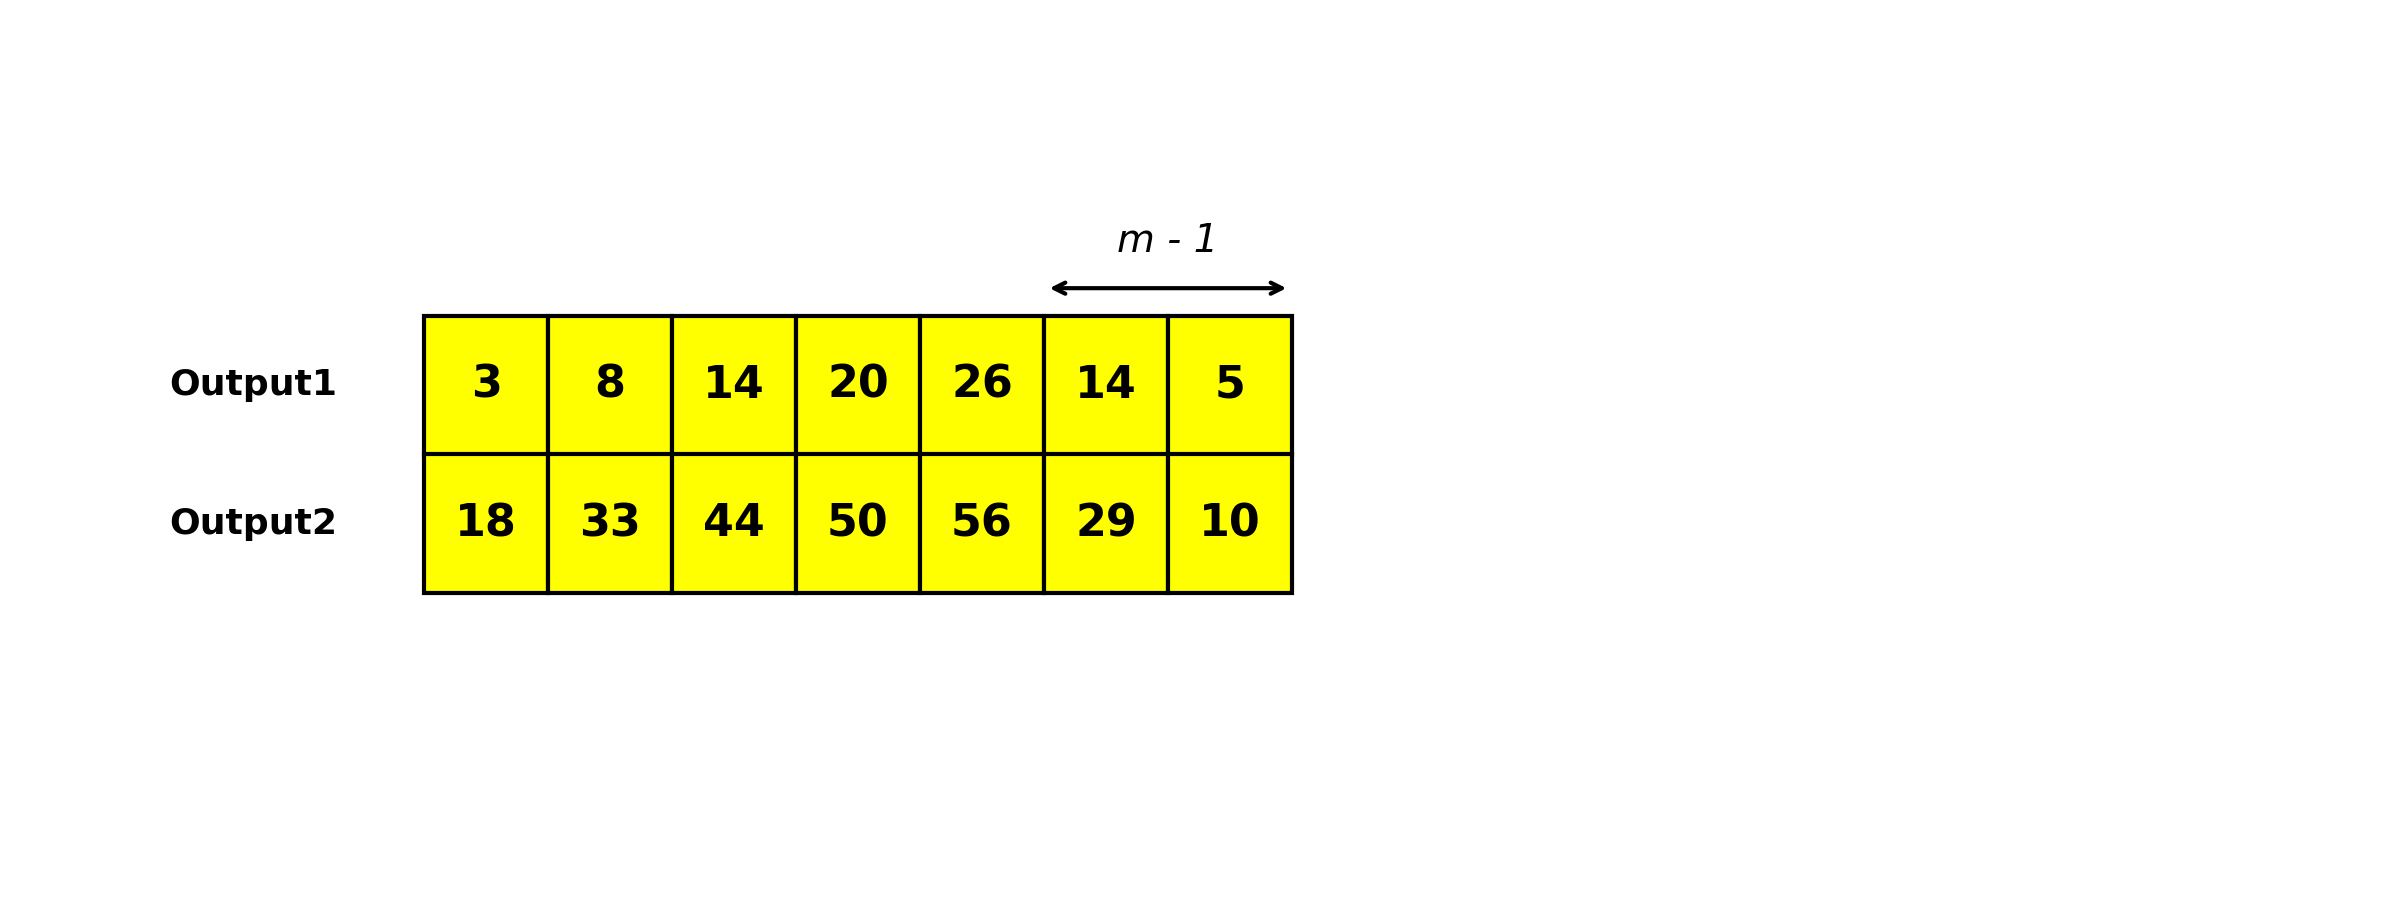

In [6]:
Image(filename='array_merge_annotated.gif', width=800, height=300)